<img src="https://media.giphy.com/media/FSzLVme5Y3n3LMOiqP/giphy.gif" width="250" height="250"/>


Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

## Questions

With your own data that you collected:
1. Create 2 graphs between two variables. Be sure to include the title, labels of both axis. Include a legend if necessary. Be sure that nothing overlaps in the graph (words or legends, etc). 

2. Write 1-2 sentences that describe the main information presented and a conclusion that you could draw from that graph. 

3. Display the graphs side by side in one figure. 

4. Do a third graph that is not a line graph or bar chart (with proper labels and titles). Make sure this third graph displays different information than presented in step 1.


In [2]:
import requests

api_key = "d9eea423"

movie = "Interstellar"

#test API to see what the data looks like 
url = f"http://www.omdbapi.com/?t={movie}&apikey={api_key}"

response = requests.get(url)
data = response.json()

print(data)

{'Title': 'Interstellar', 'Year': '2014', 'Rated': 'PG-13', 'Released': '07 Nov 2014', 'Runtime': '169 min', 'Genre': 'Adventure, Drama, Sci-Fi', 'Director': 'Christopher Nolan', 'Writer': 'Jonathan Nolan, Christopher Nolan', 'Actors': 'Matthew McConaughey, Anne Hathaway, Jessica Chastain', 'Plot': 'When Earth becomes uninhabitable in the future, a farmer and ex-NASA pilot, Joseph Cooper, is tasked to pilot a spacecraft, along with a team of researchers, to find a new planet for humans.', 'Language': 'English', 'Country': 'United States, United Kingdom, Canada', 'Awards': 'Won 1 Oscar. 45 wins & 148 nominations total', 'Poster': 'https://m.media-amazon.com/images/M/MV5BYzdjMDAxZGItMjI2My00ODA1LTlkNzItOWFjMDU5ZDJlYWY3XkEyXkFqcGc@._V1_QL75_UX380_CR0,0,380,562_.jpg', 'Ratings': [{'Source': 'Internet Movie Database', 'Value': '8.7/10'}, {'Source': 'Rotten Tomatoes', 'Value': '73%'}, {'Source': 'Metacritic', 'Value': '74/100'}], 'Metascore': '74', 'imdbRating': '8.7', 'imdbVotes': '2,516,75

In [14]:
import requests
import pandas as pd

api_key = "d9eea423"

movies = [
    "The Godfather",
    "Casablanca",
    "Citizen Kane",
    "Gone with the Wind",
    "Lawrence of Arabia",
    "The Wizard of Oz",
    "The Graduate",
    "On the Waterfront",
    "Schindler's List",
    "Singin' in the Rain",
    "It's a Wonderful Life",
    "Sunset Boulevard",
    "The Bridge on the River Kwai",
    "Some Like It Hot",
    "Star Wars",
    "All About Eve",
    "The African Queen",
    "Psycho",
    "Chinatown",
    "One Flew Over the Cuckoo's Nest",
    "The Grapes of Wrath",
    "2001: A Space Odyssey",
    "The Maltese Falcon",
    "Raging Bull",
    "E.T.",
    "Dr. Strangelove",
    "Bonnie and Clyde",
    "Apocalypse Now",
    "Mr. Smith Goes to Washington",
    "Treasure of the Sierra Madre",
    "Annie Hall",
    "The Godfather Part II",
    "High Noon",
    "To Kill a Mockingbird",
    "Rocky",
    "The Silence of the Lambs",
    "Network",
    "The Manchurian Candidate",
    "American Graffiti",
    "Raiders of the Lost Ark",
    "Vertigo",
    "Tootsie",
    "Stagecoach",
    "Close Encounters of the Third Kind",
    "The Philadelphia Story",
    "Shane",
    "It Happened One Night",
    "A Streetcar Named Desire",
    "Rear Window",
    "Forrest Gump",
    "The Shawshank Redemption",
    "Fight Club",
    "Interstellar",
    "The Matrix",
    "Pulp Fiction",
    "Goodfellas",
    "The Dark Knight",
    "Whiplash",
    "Parasite",
    "Joker",
    "Black Swan",
    "The Pianist",
    "The Green Mile",
    "Gladiator",
    "Memento",
    "The Prestige",
    "The Departed",
    "No Country for Old Men",
    "Arrival",
    "Blade Runner 2049",
    "Dune",
    "Oppenheimer",
    "Barbie",
    "Lady Bird",
    "Little Women",
    "The Notebook",
    "Manchester by the Sea",
    "Good Will Hunting",
    "Toy Story",
    "Coco",
    "Up",
    "Finding Nemo",
    "Wall-E",
    "Spirited Away",
    "Your Name",
    "City of God",
    "Seven Samurai",
    "Oldboy",
    "The Handmaiden",
    "Life Is Beautiful",
    "Pan's Labyrinth",
    "Roma",
    "Moonlight",
    "Minari",
    "Past Lives",
    "Portrait of a Lady on Fire",
    "Amélie",
    "The Florida Project",
    "Call Me by Your Name",
    "The Truman Show"
]

movie_data = []

# loop through movies and get OMDb data
for movie in movies:
    url = f"http://www.omdbapi.com/?t={movie}&apikey={api_key}"

    response = requests.get(url)
    data = response.json()

    # only keep valid responses
    if data["Response"] == "True":
        movie_data.append(data)

# turn into dataframe
df = pd.DataFrame(movie_data)



In [15]:
# Cleaning IMDb rating
df["imdbRating"] = pd.to_numeric(df["imdbRating"], errors="coerce")

# Makeing Runtime text first, then remove " min"
df["Runtime"] = df["Runtime"].astype(str)
df["Runtime"] = df["Runtime"].str.replace(" min", "")

# Turning Runtime into a number
df["Runtime"] = pd.to_numeric(df["Runtime"], errors="coerce")

df[["Title", "imdbRating", "Runtime"]]

,Title,imdbRating,Runtime
0,The Godfather,9.2,175.0
1,Casablanca,8.5,102.0
2,Citizen Kane,8.2,119.0
3,Gone with the Wind,8.2,238.0
4,Lawrence of Arabia,8.3,227.0
...,...,...,...
95,Portrait of a Lady on Fire,8.0,122.0
96,Amélie,8.3,122.0
97,The Florida Project,7.6,111.0
98,Call Me by Your Name,7.8,132.0


In [16]:
#function to turn the Awards text into a number
def awards_count(text): 
    if text == "N/A":
        return 0
    
    total = 0
    words = text.split()

    #go through each word and add numbers we find
    for w in words:
        if w.isdigit():
            total += int(w)
    
    return total

#apply function to create total awards column
df["Awards_Count"] = df["Awards"].apply(awards_count)


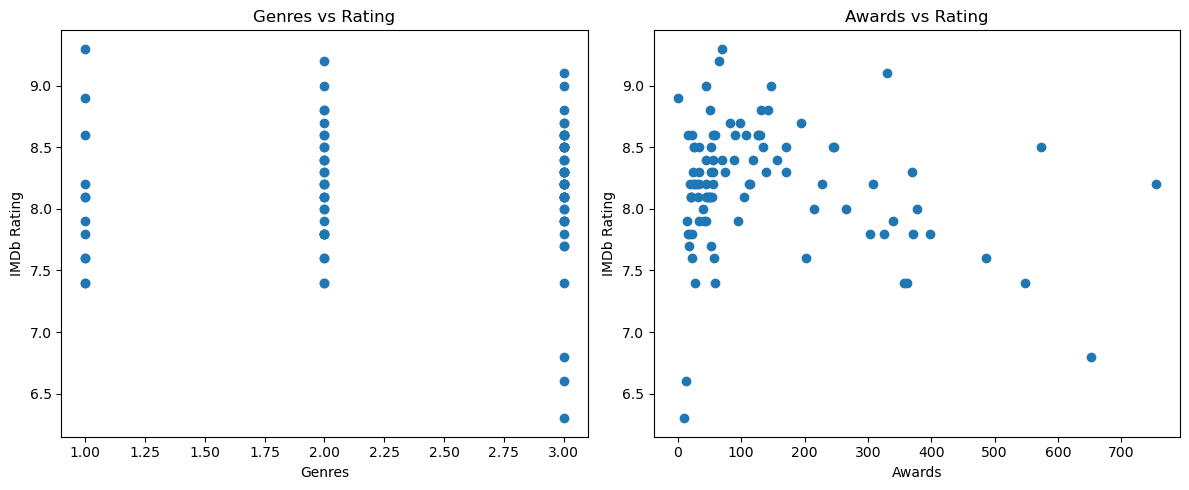

In [13]:
import matplotlib.pyplot as plt

# keep ONE of these
df["Genre_Count"] = df["Genre"].apply(lambda x: len(x.split(",")))

# graphs
plt.figure(figsize=(12,5))

# graph 1
plt.subplot(1,2,1)
plt.scatter(df["Genre_Count"], df["imdbRating"])
plt.xlabel("Genres")
plt.ylabel("IMDb Rating")
plt.title("Genres vs Rating")

# graph 2
plt.subplot(1,2,2)
plt.scatter(df["Awards_Count"], df["imdbRating"])
plt.xlabel("Awards")
plt.ylabel("IMDb Rating")
plt.title("Awards vs Rating")

plt.tight_layout()
plt.show()

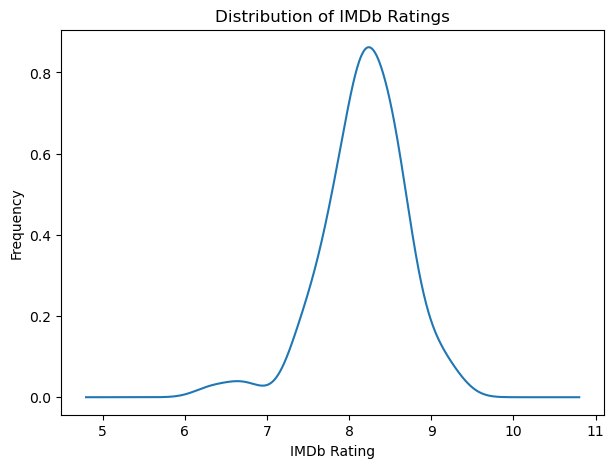

In [17]:
plt.figure(figsize=(7,5))

df["imdbRating"].plot(kind="density")

plt.title("Distribution of IMDb Ratings")
plt.xlabel("IMDb Rating")
plt.ylabel("Frequency")

plt.show()